In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import style
style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
data = pd.read_csv('CO2 Emissions_Canada.csv')
data.head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [4]:
data.nunique()

Make                                  42
Model                               2053
Vehicle Class                         16
Engine Size(L)                        51
Cylinders                              8
Transmission                          27
Fuel Type                              5
Fuel Consumption City (L/100 km)     211
Fuel Consumption Hwy (L/100 km)      143
Fuel Consumption Comb (L/100 km)     181
Fuel Consumption Comb (mpg)           54
CO2 Emissions(g/km)                  331
dtype: int64

In [5]:
data['Fuel Type'].unique()

array(['Z', 'D', 'X', 'E', 'N'], dtype=object)

In [6]:
data['Vehicle Class'].unique()

array(['COMPACT', 'SUV - SMALL', 'MID-SIZE', 'TWO-SEATER', 'MINICOMPACT',
       'SUBCOMPACT', 'FULL-SIZE', 'STATION WAGON - SMALL',
       'SUV - STANDARD', 'VAN - CARGO', 'VAN - PASSENGER',
       'PICKUP TRUCK - STANDARD', 'MINIVAN', 'SPECIAL PURPOSE VEHICLE',
       'STATION WAGON - MID-SIZE', 'PICKUP TRUCK - SMALL'], dtype=object)

In [7]:
data['Cylinders'].unique()

array([ 4,  6, 12,  8, 10,  3,  5, 16], dtype=int64)

In [8]:
data['Transmission'].unique()

array(['AS5', 'M6', 'AV7', 'AS6', 'AM6', 'A6', 'AM7', 'AV8', 'AS8', 'A7',
       'A8', 'M7', 'A4', 'M5', 'AV', 'A5', 'AS7', 'A9', 'AS9', 'AV6',
       'AS4', 'AM5', 'AM8', 'AM9', 'AS10', 'A10', 'AV10'], dtype=object)

In [9]:
# check for duplicates
data.duplicated().sum()

1103

In [10]:
# Drop duplicates
data.drop_duplicates(inplace = True)
data.duplicated().sum()

0

In [11]:
# Check for missing values
data.isnull().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

### Exploratory data Analysis

<Axes: xlabel='Engine Size(L)', ylabel='CO2 Emissions(g/km)'>

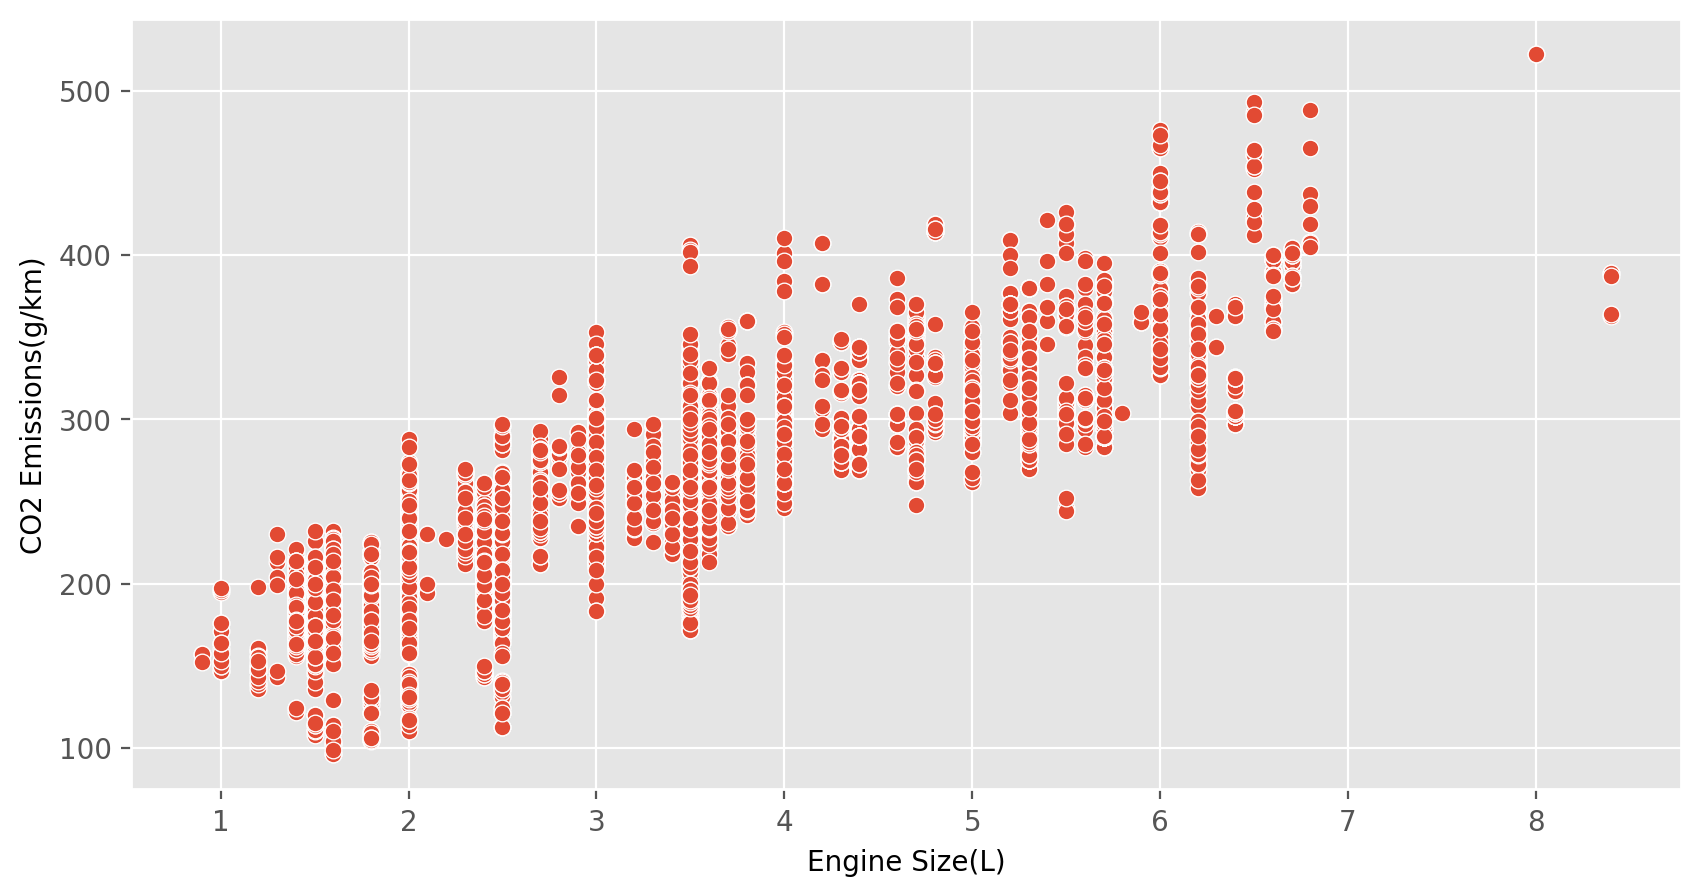

In [12]:
plt.figure(figsize = (10,5), dpi = 200)
sns.scatterplot(x = 'Engine Size(L)', y = 'CO2 Emissions(g/km)', data = data)

<b> CO2 Emissions(g/km) increases with Engine Size(L)

<Axes: xlabel='Engine Size(L)', ylabel='CO2 Emissions(g/km)'>

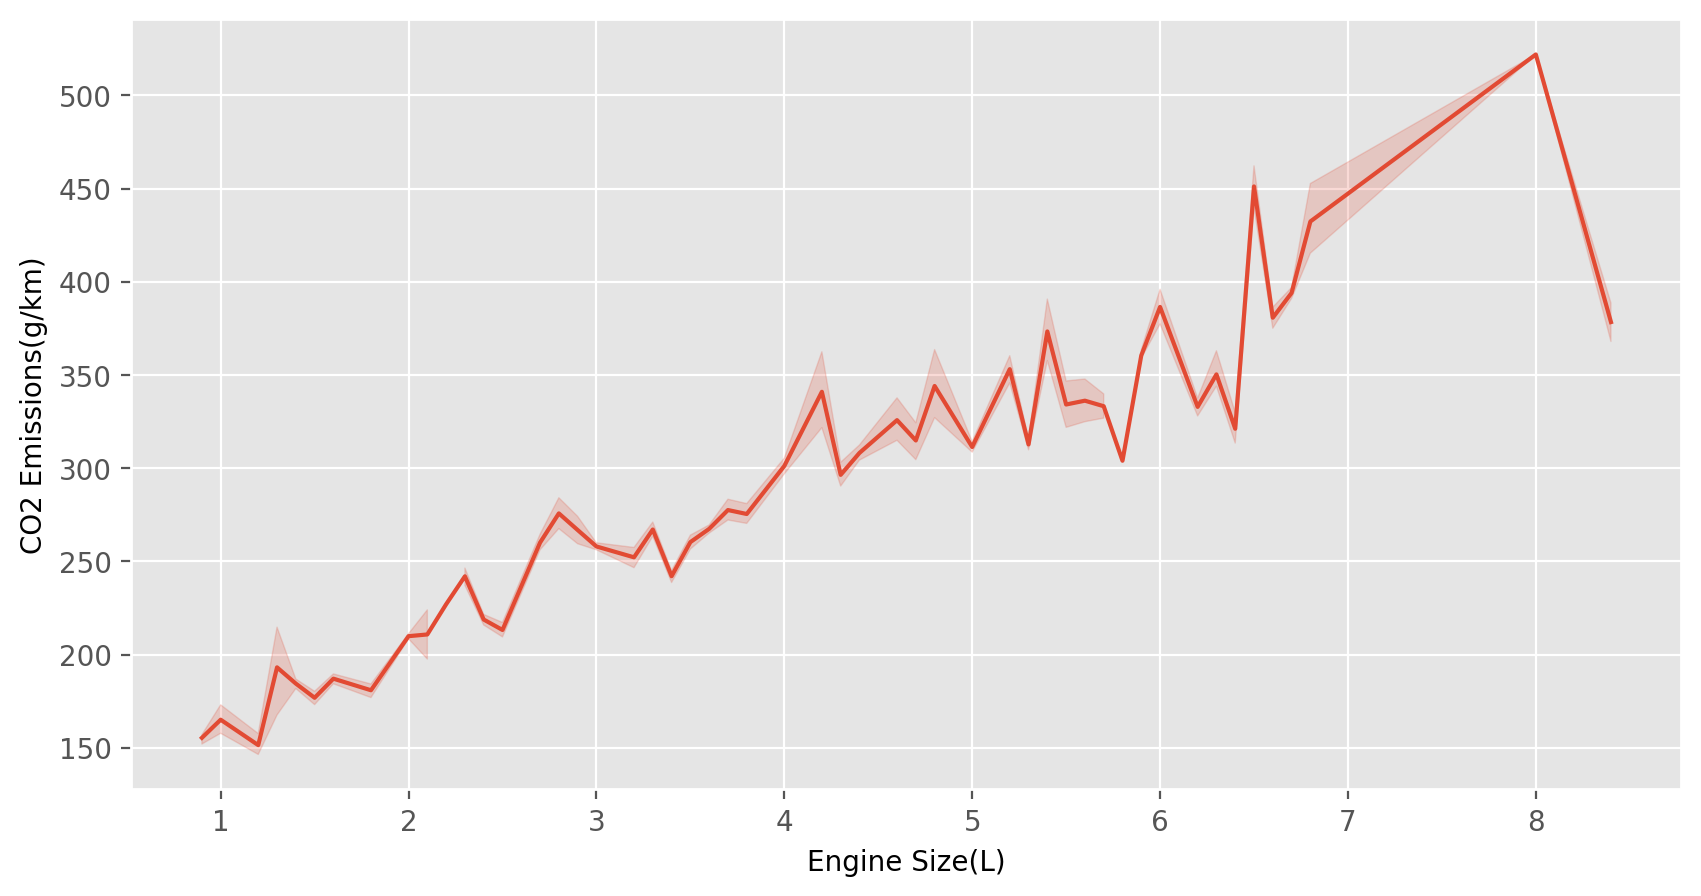

In [13]:
plt.figure(figsize = (10,5), dpi = 200)
sns.lineplot(x = 'Engine Size(L)', y = 'CO2 Emissions(g/km)', data = data)

### Here scatterplot is much better

<Axes: xlabel='Fuel Type', ylabel='CO2 Emissions(g/km)'>

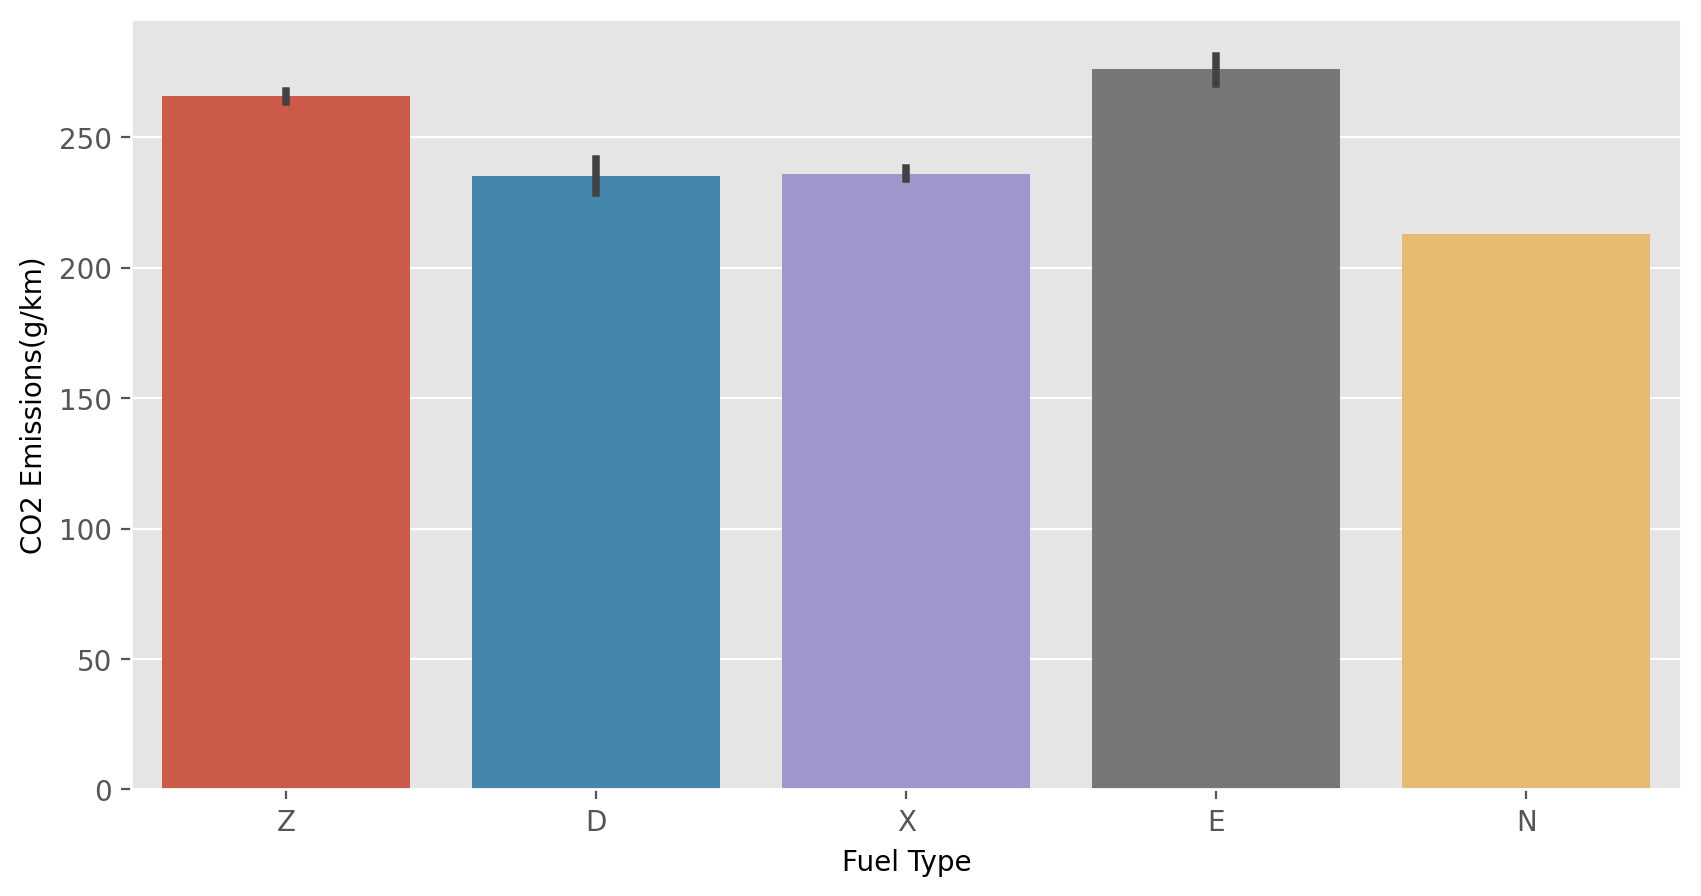

In [15]:
plt.figure(figsize = (10,5), dpi = 200)
sns.barplot(x = 'Fuel Type', y = 'CO2 Emissions(g/km)', data = data)

<b> It is not very significant but 'E' Type of Fuel has highest Carbon Emission

<Axes: xlabel='Fuel Type', ylabel='CO2 Emissions(g/km)'>

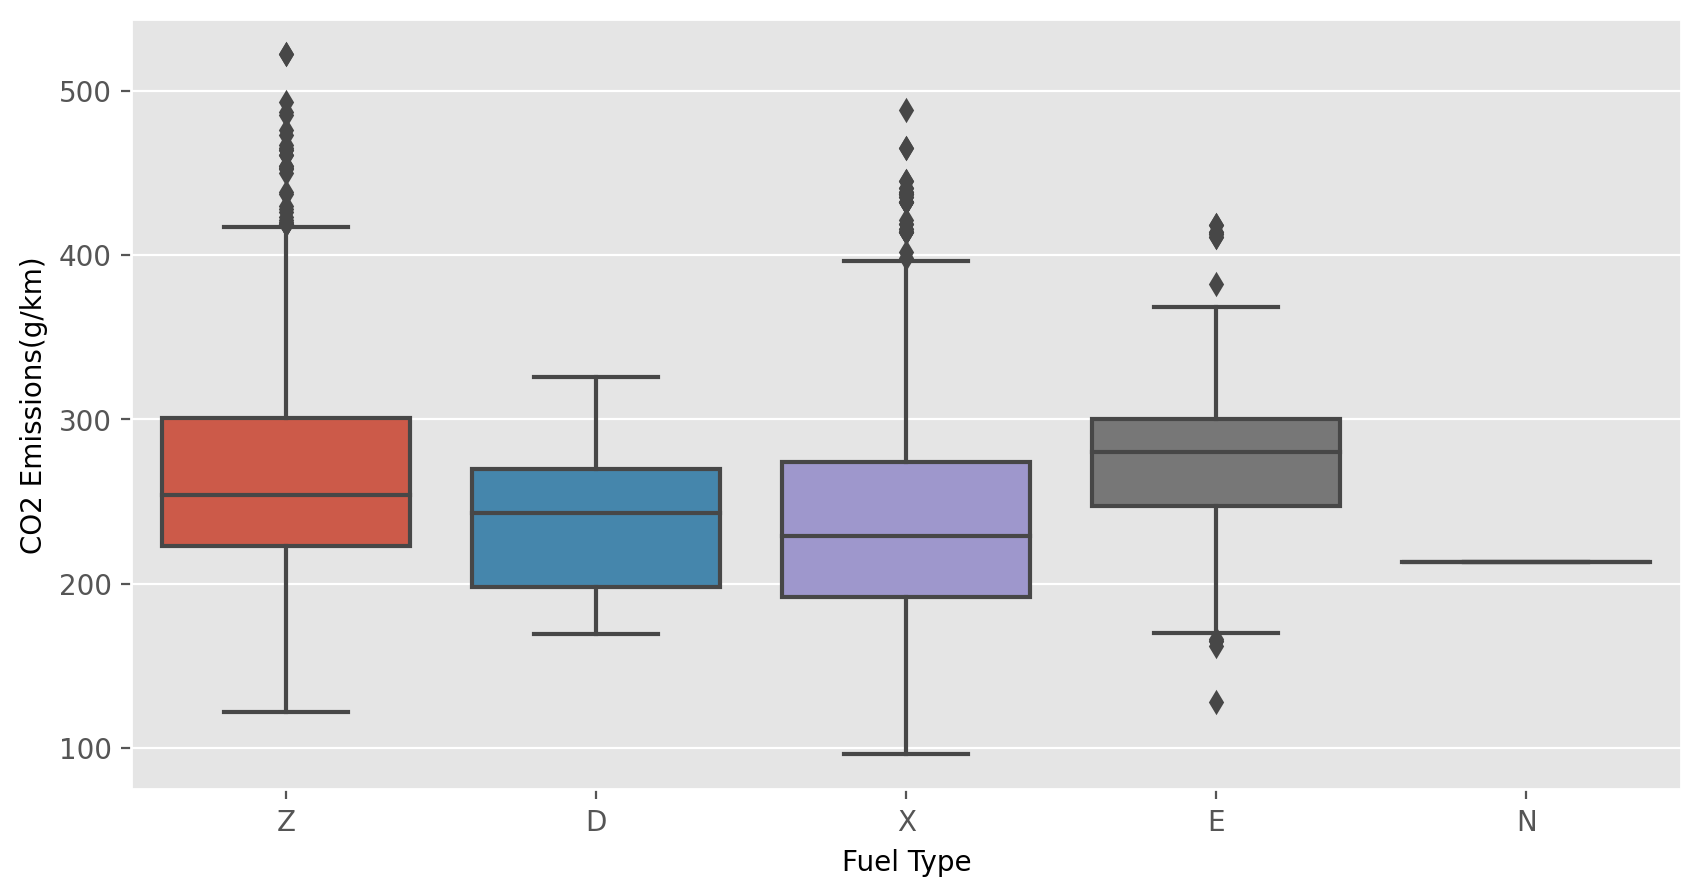

In [16]:
plt.figure(figsize = (10,5), dpi = 200)
sns.boxplot(x = 'Fuel Type', y = 'CO2 Emissions(g/km)', data = data)

In [17]:
# Here boxplot is better

<Axes: xlabel='Cylinders', ylabel='CO2 Emissions(g/km)'>

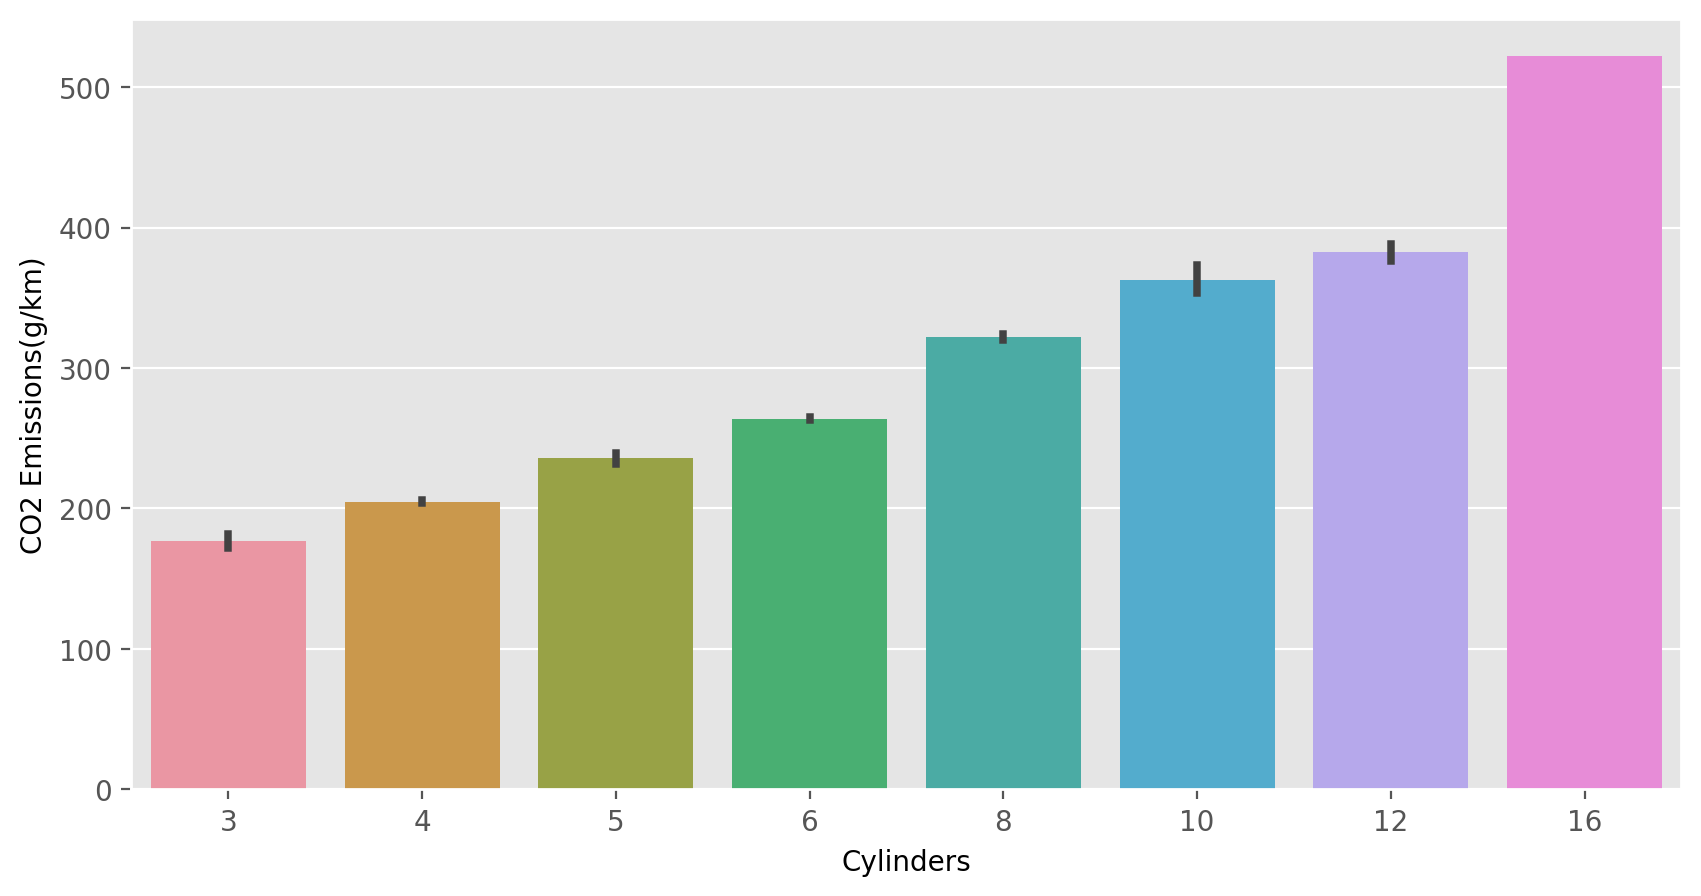

In [18]:
plt.figure(figsize = (10,5), dpi = 200)
sns.barplot(x = 'Cylinders', y = 'CO2 Emissions(g/km)', data = data)

<b> 16 Cylinders Vehichle have highest Carbon Emission then 12,10,8...... and so on. we can say that no of cylinder increases Carbon Emission has also increases And it also confirm the finding our engine size beacause More number of cylinder bigger engine,the same pattern as shown in engine size also ,they are complementing each other

<Axes: xlabel='Cylinders', ylabel='CO2 Emissions(g/km)'>

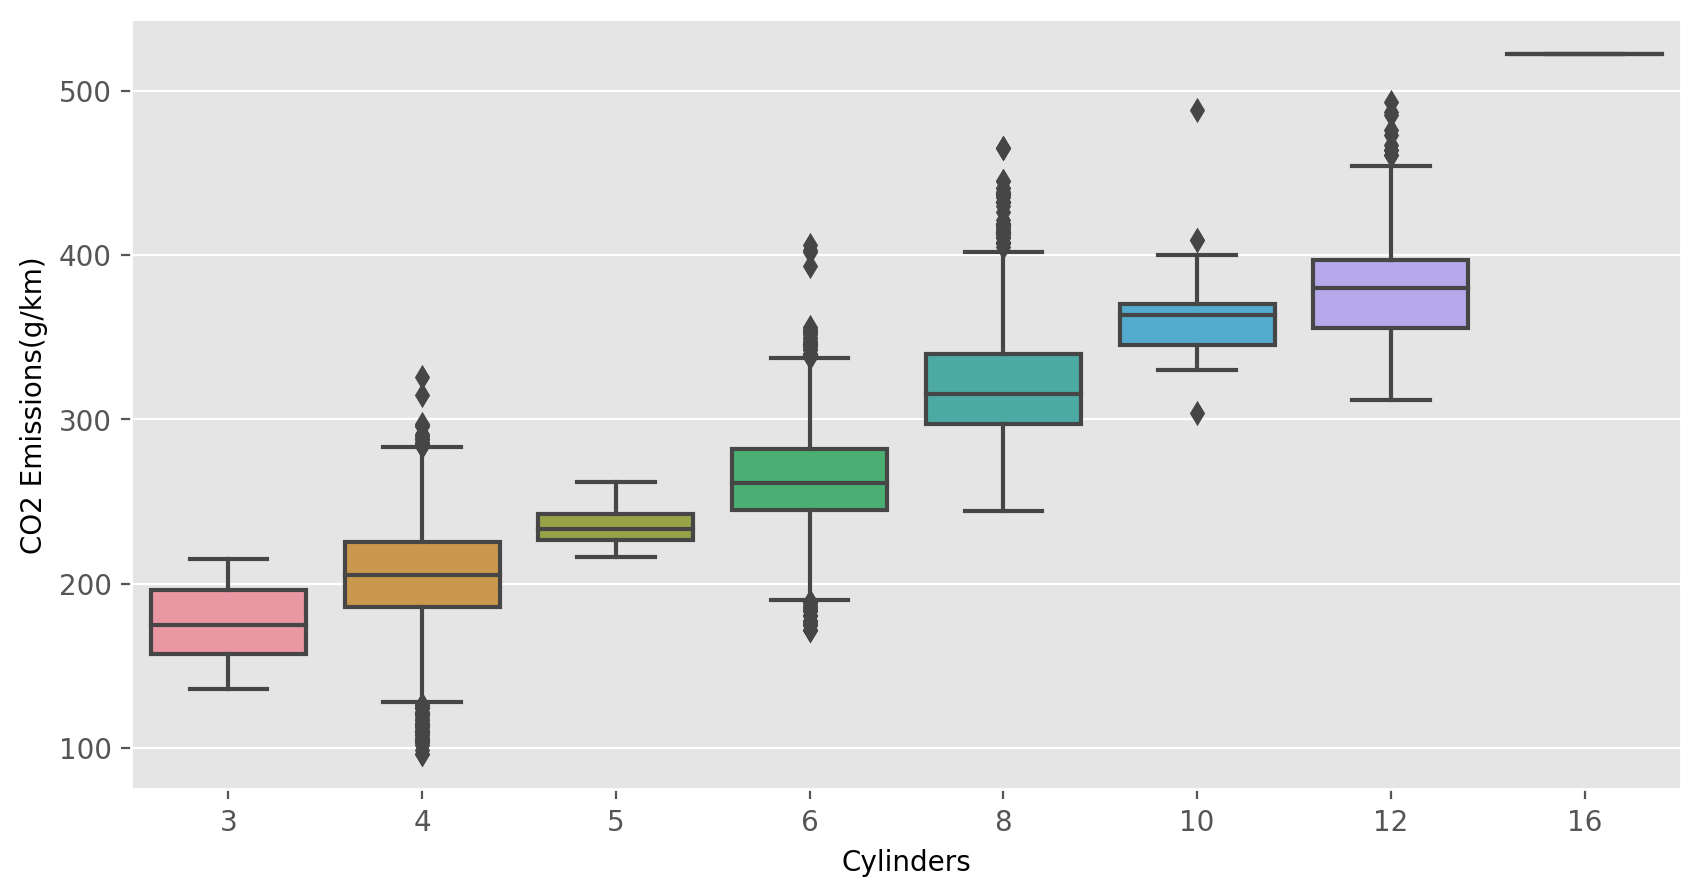

In [19]:
plt.figure(figsize = (10,5), dpi = 200)
sns.boxplot(x = 'Cylinders', y = 'CO2 Emissions(g/km)', data = data)

<Axes: xlabel='Fuel Consumption Comb (L/100 km)', ylabel='CO2 Emissions(g/km)'>

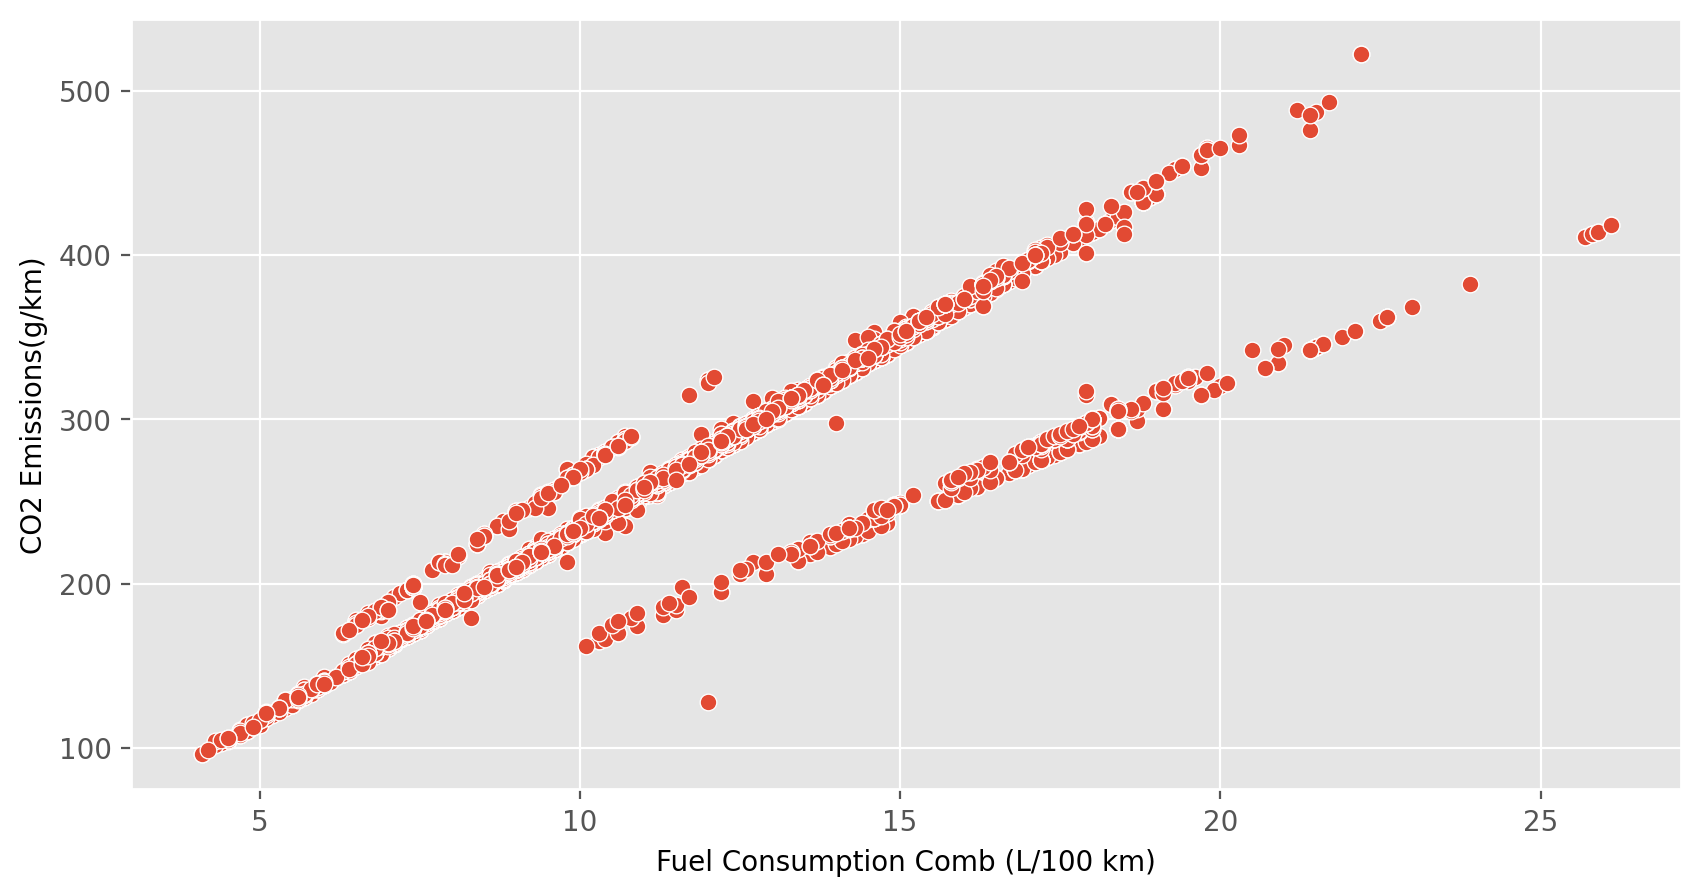

In [20]:
plt.figure(figsize = (10,5), dpi = 200)
sns.scatterplot(x = 'Fuel Consumption Comb (L/100 km)', y = 'CO2 Emissions(g/km)', data = data)

<b> As Vehicle is consuming more Fuel, clearly, Carbon Emission is also increasing

<Axes: xlabel='Fuel Consumption Comb (L/100 km)', ylabel='CO2 Emissions(g/km)'>

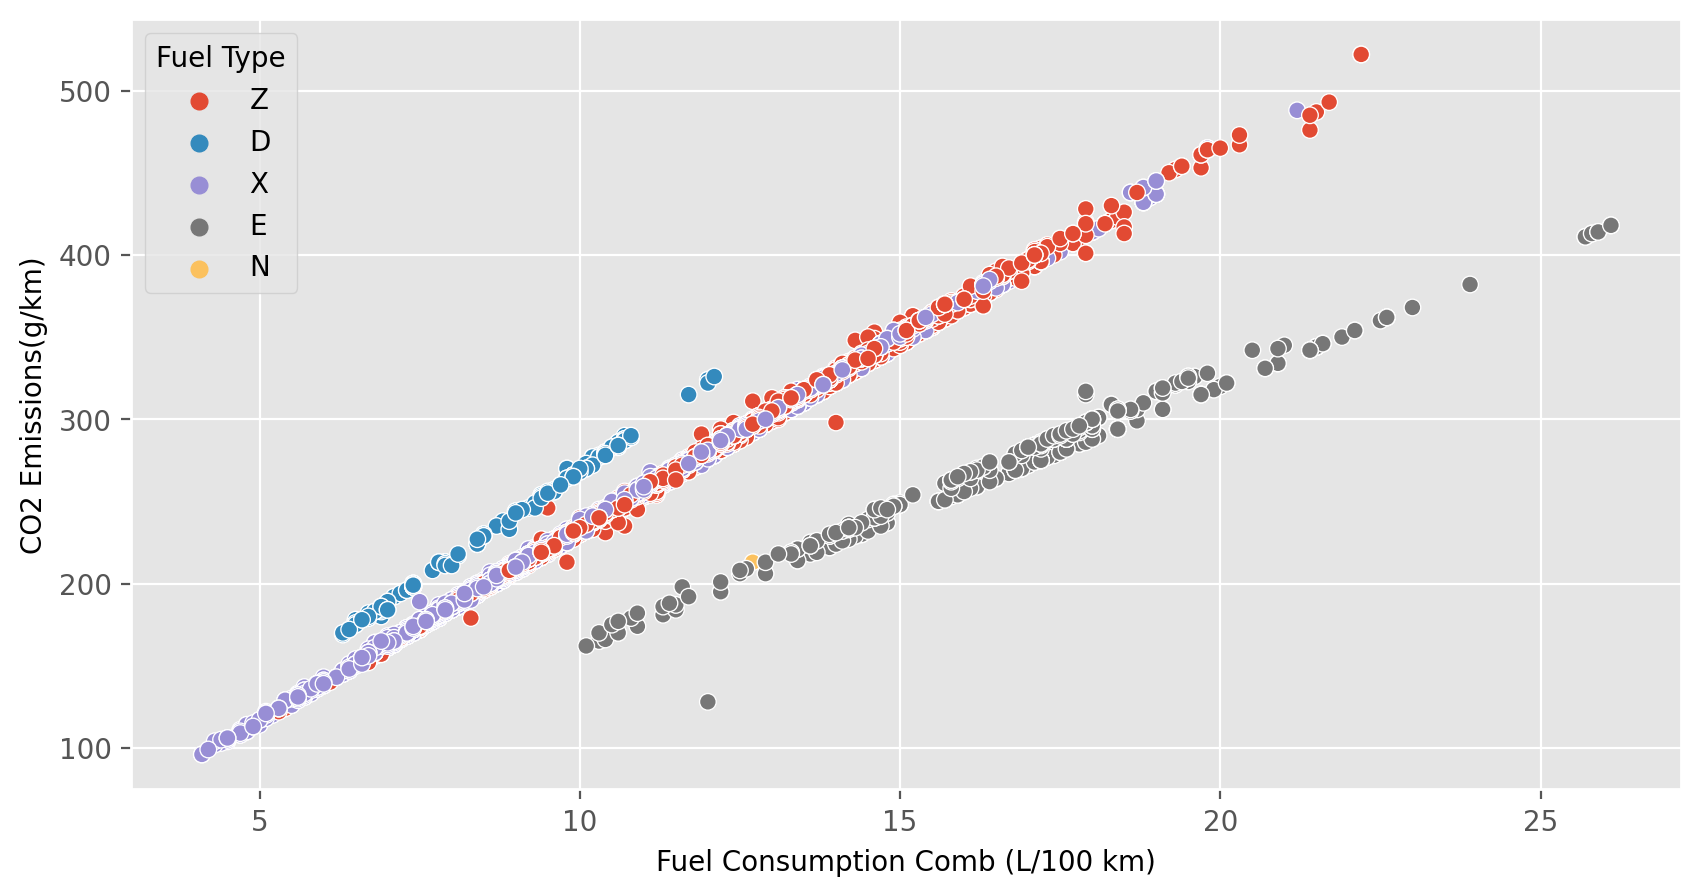

In [21]:
plt.figure(figsize = (10,5), dpi = 200)
sns.scatterplot(x = 'Fuel Consumption Comb (L/100 km)', y = 'CO2 Emissions(g/km)',hue = 'Fuel Type', data = data)

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Vehicle Class'>

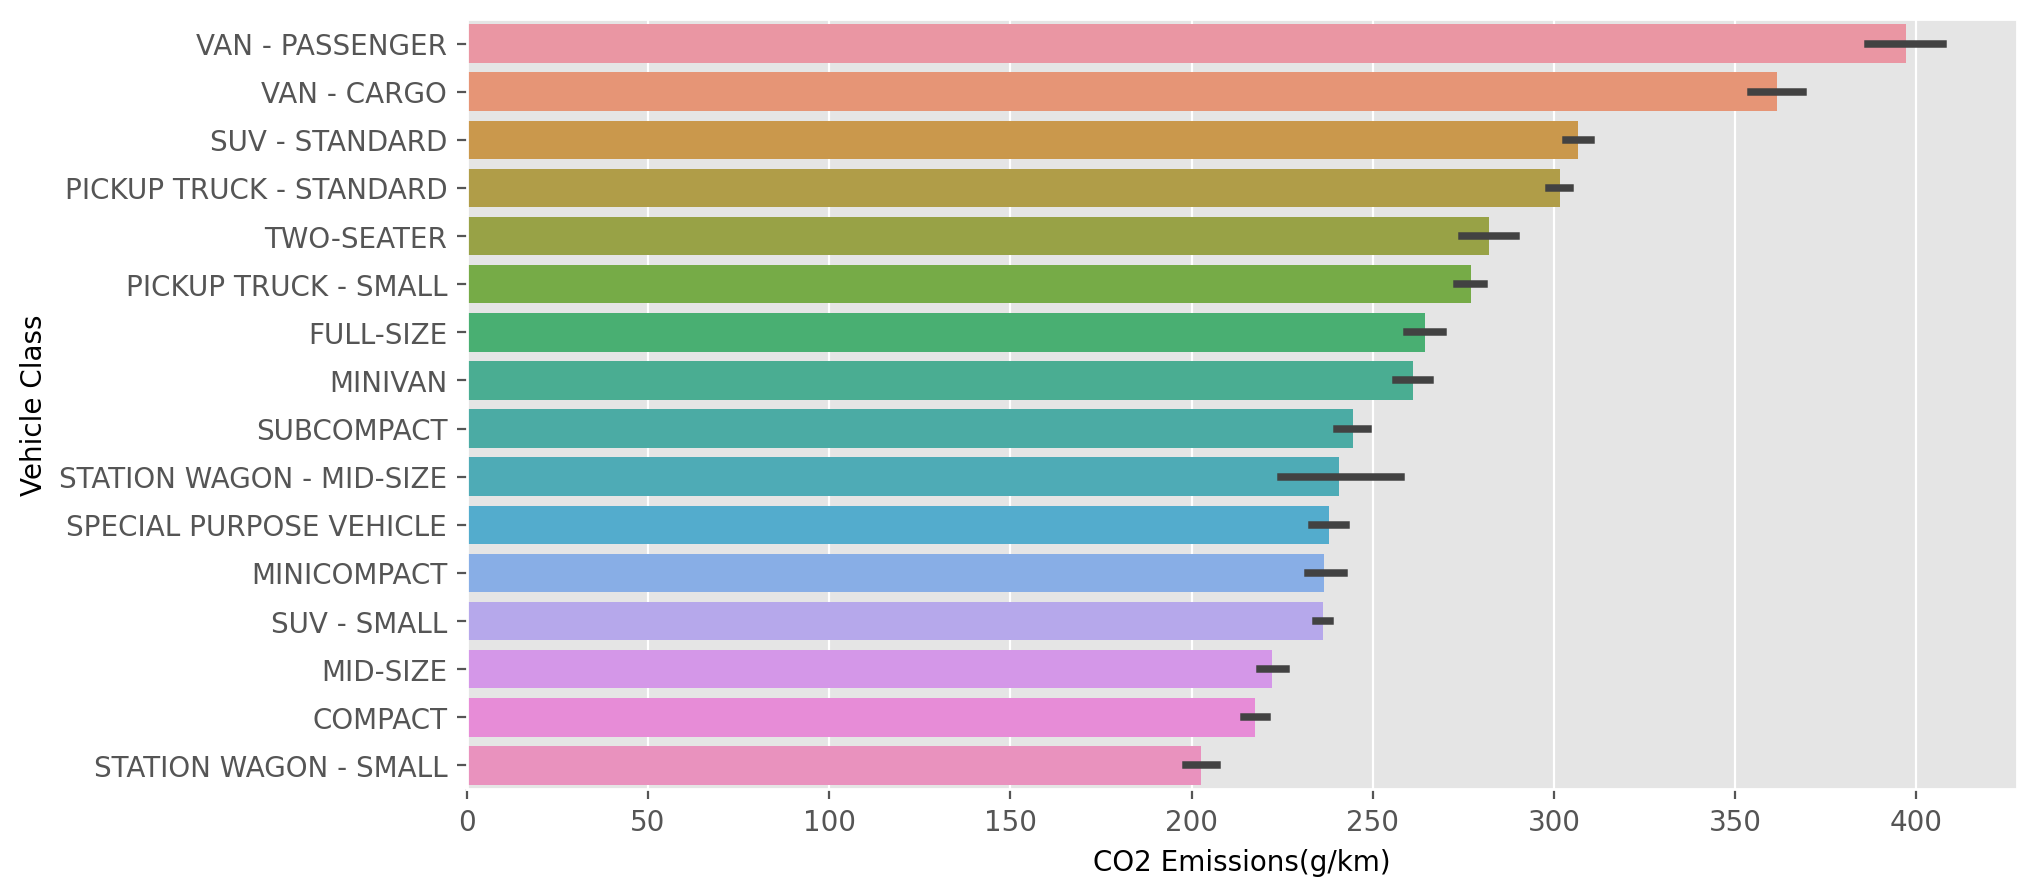

In [22]:
order = data.groupby('Vehicle Class').mean().sort_values('CO2 Emissions(g/km)', ascending = False).index
plt.figure(figsize = (10,5), dpi = 200)
sns.barplot(x = 'CO2 Emissions(g/km)', y = 'Vehicle Class', data = data, order = order)

<b> Passenger Van has highest Emission

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Vehicle Class'>

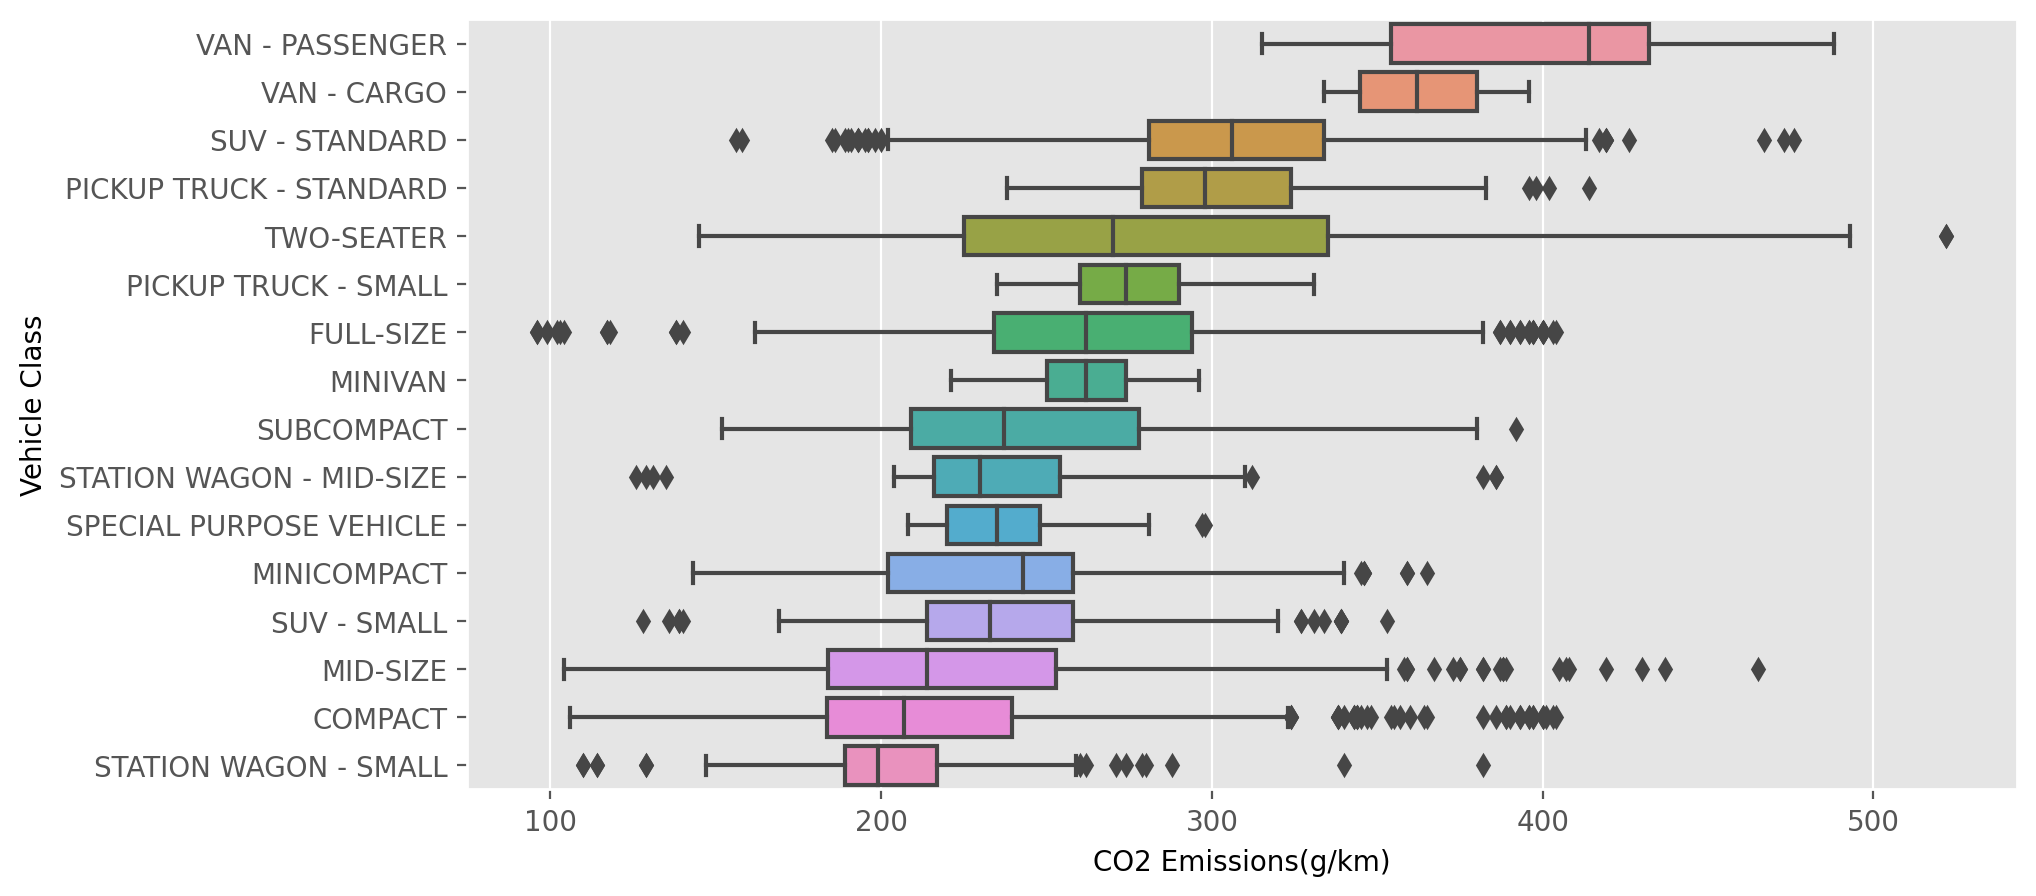

In [23]:
order = data.groupby('Vehicle Class').mean().sort_values('CO2 Emissions(g/km)', ascending = False).index
plt.figure(figsize = (10,5), dpi = 200)
sns.boxplot(x = 'CO2 Emissions(g/km)', y = 'Vehicle Class', data = data, order = order)

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Transmission'>

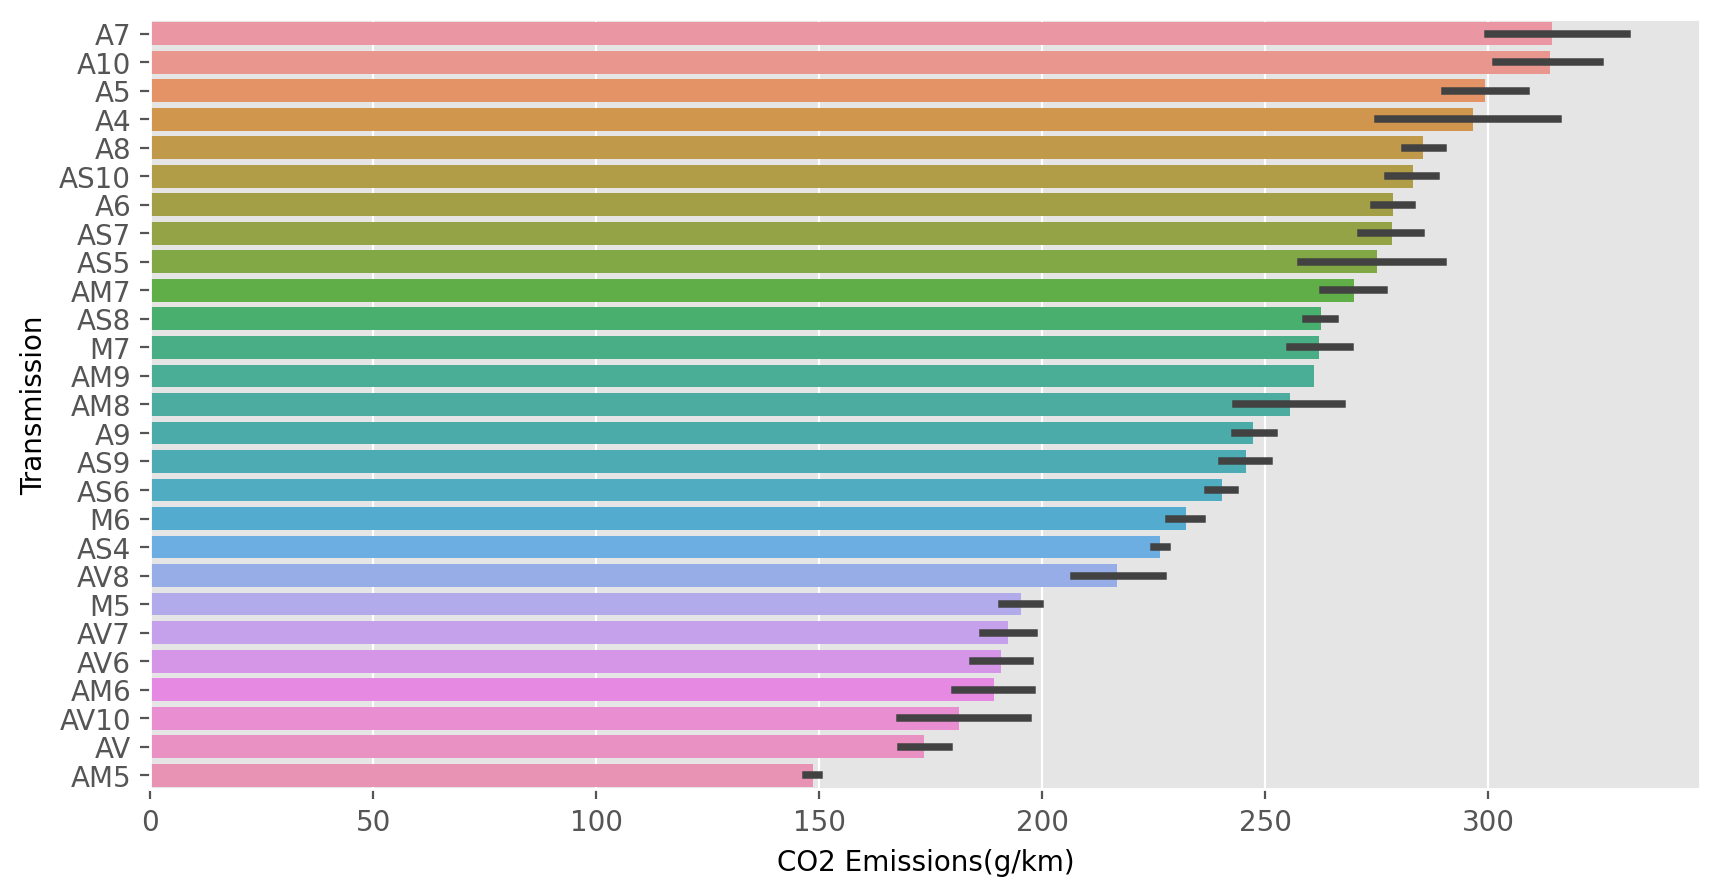

In [24]:
order = data.groupby('Transmission').mean().sort_values('CO2 Emissions(g/km)', ascending = False).index
plt.figure(figsize = (10,5), dpi = 200)
sns.barplot(x = 'CO2 Emissions(g/km)', y = 'Transmission', data = data, order = order)

<Axes: >

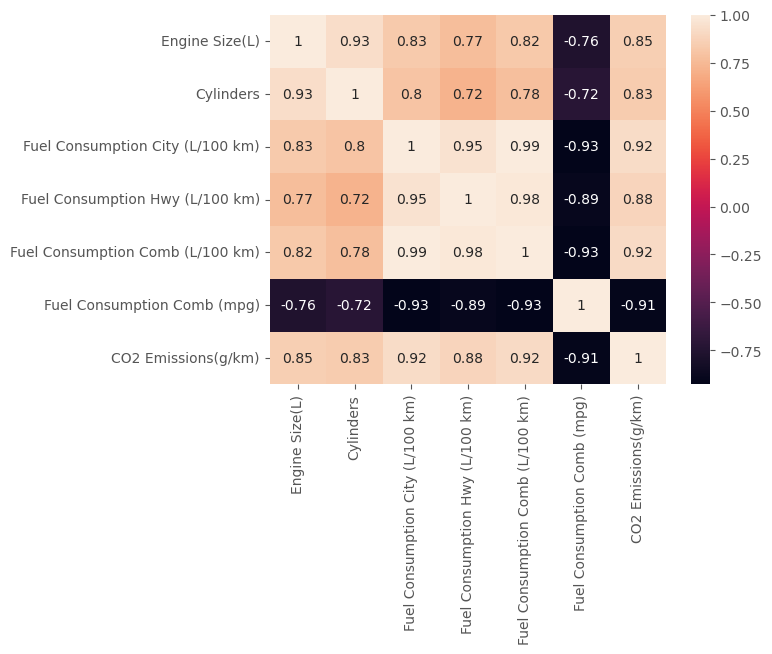

In [25]:
plt.figure(dpi = 100)
sns.heatmap(data.corr(), annot = True)

In [26]:
cols = ['Vehicle Class','Transmission', 'Fuel Type', 'Cylinders','Engine Size(L)', 'Fuel Consumption Comb (L/100 km)']
X = data[cols]
Y = data[['CO2 Emissions(g/km)']]

In [27]:
X.head(5)

,Vehicle Class,Transmission,Fuel Type,Cylinders,Engine Size(L),Fuel Consumption Comb (L/100 km)
0,COMPACT,AS5,Z,4,2.0,8.5
1,COMPACT,M6,Z,4,2.4,9.6
2,COMPACT,AV7,Z,4,1.5,5.9
3,SUV - SMALL,AS6,Z,6,3.5,11.1
4,SUV - SMALL,AS6,Z,6,3.5,10.6


In [28]:
Y.head(5)

,CO2 Emissions(g/km)
0,196
1,221
2,136
3,255
4,244


In [29]:
print('Independent Feature Set Shape : ', X.shape) 
print('Dependent Feature Set Shape   : ', Y.shape)

Independent Feature Set Shape :  (6282, 6)
Dependent Feature Set Shape   :  (6282, 1)


In [30]:
# Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols = ['Engine Size(L)', 'Fuel Consumption Comb (L/100 km)']
X[cols] = scaler.fit_transform(X[cols])
X.head(5)

,Vehicle Class,Transmission,Fuel Type,Cylinders,Engine Size(L),Fuel Consumption Comb (L/100 km)
0,COMPACT,AS5,Z,4,0.146667,0.200000
1,COMPACT,M6,Z,4,0.200000,0.250000
2,COMPACT,AV7,Z,4,0.080000,0.081818
3,SUV - SMALL,AS6,Z,6,0.346667,0.318182
4,SUV - SMALL,AS6,Z,6,0.346667,0.295455


In [31]:
# Dealing wit categorical values
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
cols = ['Vehicle Class','Transmission', 'Fuel Type']
X[cols] = encoder.fit_transform(X[cols])
X.head(10)

,Vehicle Class,Transmission,Fuel Type,Cylinders,Engine Size(L),Fuel Consumption Comb (L/100 km)
0,0.0,14.0,4.0,4,0.146667,0.200000
1,0.0,25.0,4.0,4,0.200000,0.250000
2,0.0,22.0,4.0,4,0.080000,0.081818
3,11.0,15.0,4.0,6,0.346667,0.318182
4,11.0,15.0,4.0,6,0.346667,0.295455
5,2.0,15.0,4.0,6,0.346667,0.268182
6,2.0,15.0,4.0,6,0.346667,0.272727
7,2.0,15.0,4.0,6,0.373333,0.318182
8,2.0,25.0,4.0,6,0.373333,0.340909
9,0.0,14.0,4.0,4,0.200000,0.231818


In [32]:
# Splitting the data into train and test sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25)

In [33]:
print('Training Data Shape   : ', x_train.shape)
print('Training Labels Shape : ', y_train.shape)
print('Testing Data Shape    : ', x_test.shape)
print('Testing Labels Shape  : ', y_test.shape)

Training Data Shape   :  (4711, 6)
Training Labels Shape :  (4711, 1)
Testing Data Shape    :  (1571, 6)
Testing Labels Shape  :  (1571, 1)


In [34]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

- Y' = B0 + B1*x1 + B2*x2 + B3*x3 + B4*x4 + B5*x5 + B6*x6

In [35]:
regressor.intercept_                                    # B0

array([81.26940287])

In [36]:
regressor.coef_                                         # B1, B2, B3, B4, B5, B6

array([[ 8.31319774e-01, -1.02354905e-01,  1.02507637e+01,
         4.11529772e+00,  5.21529454e+01,  2.98455865e+02]])

In [37]:
regressor.predict(x_test[0:1])

array([[292.45720655]])

In [38]:
pred_train = regressor.predict(x_train)
pred_test  = regressor.predict(x_test)

In [39]:
from sklearn.metrics import r2_score
print('Training set score : ', r2_score(y_train, pred_train))
print('Testing set score  : ', r2_score(y_test, pred_test))

Training set score :  0.900464570535052
Testing set score  :  0.9106912784036718
